# Quantum Dynamics: Rabi Oscillation Parameter Inference

Infer the Rabi frequency of a driven two-level system from sparse noisy excited-state population measurements. The quantum regressor is assembled from package embedding, ansatz, optimizer, training-loop, and metric utilities, then compared with a ridge baseline.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Rabi oscillations describe coherent population transfer in a driven two-level quantum system. The inverse task is to recover the Rabi frequency from sparse noisy excited-state population measurements.

**Explicit variables.** `Omega` or `omega` is the Rabi frequency to infer. `times` contains the population-measurement times. The forward model is `P_e(t) = sin^2(Omega t / 2)`. `populations` is the measured feature matrix. `omega_min` and `omega_max` define the sampled frequency range. `y_scaled` is the scaled training target. `q_omega_pred` and `ridge_omega_pred` are held-out Rabi-frequency estimates from the quantum model and ridge baseline.

**Quantum advantage context.** Quantum models are naturally compatible with oscillatory and phase-like features, and quantum feature maps can encode nonlinear periodic structure. This notebook does **not** prove quantum advantage; it demonstrates a package-client quantum inverse model on a quantum-dynamics problem and keeps a classical baseline for calibration.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from qml.reporting import print_section


from sklearn.linear_model import Ridge

from qml.ansatz import apply_hardware_efficient_ansatz, parameter_shape
from qml.embeddings import apply_angle_embedding
from qml.metrics import mean_absolute_error, mean_squared_error
from qml.optimizers import get_optimizer
from qml.training import run_training_loop

## Domain simulator

For resonant Rabi oscillations, the excited-state population is `P_e(t) = sin^2(Omega t / 2)`. The inverse problem is to recover `Omega` from a few noisy population measurements.

In [2]:
rng = np.random.default_rng(23)
n_samples = 58
omega_min, omega_max = 0.7, 2.4
omega = rng.uniform(omega_min, omega_max, size=n_samples)
times = np.asarray([0.45, 0.95, 1.55])

populations = np.sin(0.5 * omega[:, None] * times[None, :]) ** 2
populations = np.clip(populations + rng.normal(0.0, 0.015, size=populations.shape), 0.0, 1.0)
y_scaled = 2.0 * (omega - omega_min) / (omega_max - omega_min) - 1.0

x_train, x_test, y_train, y_test, omega_train, omega_test = train_test_split(
    populations, y_scaled, omega, test_size=0.3, random_state=23
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Samples", int(n_samples)),
        ("feature_shape", list(populations.shape)),
        ("Measurement times", times.tolist()),
        ("Omega range", [float(omega.min()), float(omega.max())]),
    ],
)

Dataset
+-------------------+---------------------+
| Metric            | Value               |
+-------------------+---------------------+
| Samples           | 58                  |
| feature_shape     | [58, 3]             |
| Measurement times | [0.45, 0.95, 1.55]  |
| Omega range       | [0.721799, 2.38716] |
+-------------------+---------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

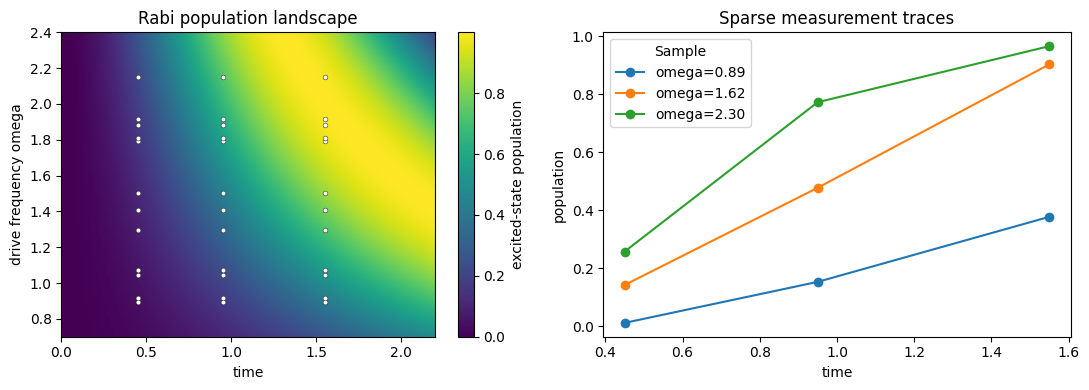

In [3]:
omega_grid = np.linspace(omega_min, omega_max, 120)
time_grid = np.linspace(0.0, 2.2, 140)
population_map = np.sin(0.5 * omega_grid[:, None] * time_grid[None, :]) ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(
    population_map,
    aspect="auto",
    origin="lower",
    extent=[time_grid.min(), time_grid.max(), omega_grid.min(), omega_grid.max()],
    cmap="viridis",
)
axes[0].scatter(np.tile(times, 12), np.repeat(omega[:12], len(times)), s=12, color="white", edgecolor="black", linewidth=0.3)
axes[0].set_title("Rabi population landscape")
axes[0].set_xlabel("time")
axes[0].set_ylabel("drive frequency omega")
fig.colorbar(im, ax=axes[0], label="excited-state population")
for idx in np.argsort(omega)[[3, len(omega) // 2, -4]]:
    axes[1].plot(times, populations[idx], "o-", label=f"omega={omega[idx]:.2f}")
axes[1].set_title("Sparse measurement traces")
axes[1].set_xlabel("time")
axes[1].set_ylabel("population")
axes[1].legend(title="Sample")
plt.tight_layout()
plt.show()


## Package-client quantum inverse model

In [4]:
def train_small_vqr(x_train, y_train, *, seed, n_layers=2, steps=70, step_size=0.07):
    n_qubits = x_train.shape[1]
    wires = list(range(n_qubits))
    dev = pl.device("default.qubit", wires=n_qubits, seed=seed)

    @pl.qnode(dev, interface="autograd")
    def circuit(sample, params):
        apply_angle_embedding(sample, wires=wires)
        apply_hardware_efficient_ansatz(params, wires=wires)
        return pl.expval(pl.PauliZ(wires[0]))

    def predict_batch(samples, params):
        return pnp.array([circuit(sample, params) for sample in samples])

    def cost(params):
        preds = predict_batch(x_train, params)
        return pnp.mean((preds - pnp.asarray(y_train, dtype=float)) ** 2)

    rng = np.random.default_rng(seed)
    init = 0.01 * rng.standard_normal(parameter_shape(n_layers=n_layers, n_qubits=n_qubits))
    params = pnp.array(init, requires_grad=True)
    opt = get_optimizer("adam", stepsize=step_size)

    def step_fn(current_params):
        return opt.step_and_cost(cost, current_params)

    params, loss_history = run_training_loop(step_fn, params, steps)

    def predict(samples):
        return np.asarray(predict_batch(samples, params), dtype=float)

    return params, loss_history, predict

In [5]:
params, loss_history, predict = train_small_vqr(
    x_train, y_train, seed=23, n_layers=2, steps=72, step_size=0.07
)


def unscale_omega(y_value):
    return omega_min + 0.5 * (np.asarray(y_value) + 1.0) * (omega_max - omega_min)


q_scaled_pred = np.clip(predict(x_test), -1.0, 1.0)
q_omega_pred = unscale_omega(q_scaled_pred)

ridge = Ridge(alpha=1e-3)
ridge.fit(x_train, y_train)
ridge_omega_pred = unscale_omega(np.clip(ridge.predict(x_test), -1.0, 1.0))

results = {
    "quantum_omega_mae": mean_absolute_error(omega_test, q_omega_pred),
    "quantum_omega_mse": mean_squared_error(omega_test, q_omega_pred),
    "ridge_omega_mae": mean_absolute_error(omega_test, ridge_omega_pred),
    "initial_loss": float(loss_history[0]),
    "final_loss": float(loss_history[-1]),
    "loss_steps": len(loss_history),
}

print_section(
    "Results",
    [
        ("Quantum omega MAE", results["quantum_omega_mae"]),
        ("Quantum omega MSE", results["quantum_omega_mse"]),
        ("Ridge omega MAE", results["ridge_omega_mae"]),
        ("Initial loss", results["initial_loss"]),
        ("Final loss", results["final_loss"]),
        ("Loss steps", results["loss_steps"]),
    ],
)

Results
+-------------------+------------+
| Metric            | Value      |
+-------------------+------------+
| Quantum omega MAE | 0.0393237  |
| Quantum omega MSE | 0.00319466 |
| Ridge omega MAE   | 0.0273694  |
| Initial loss      | 0.580552   |
| Final loss        | 0.00697781 |
| Loss steps        | 72         |
+-------------------+------------+



## Plots

The plots show the simulated measurement curves, quantum-regressor training loss, and recovered Rabi frequencies on the held-out set.

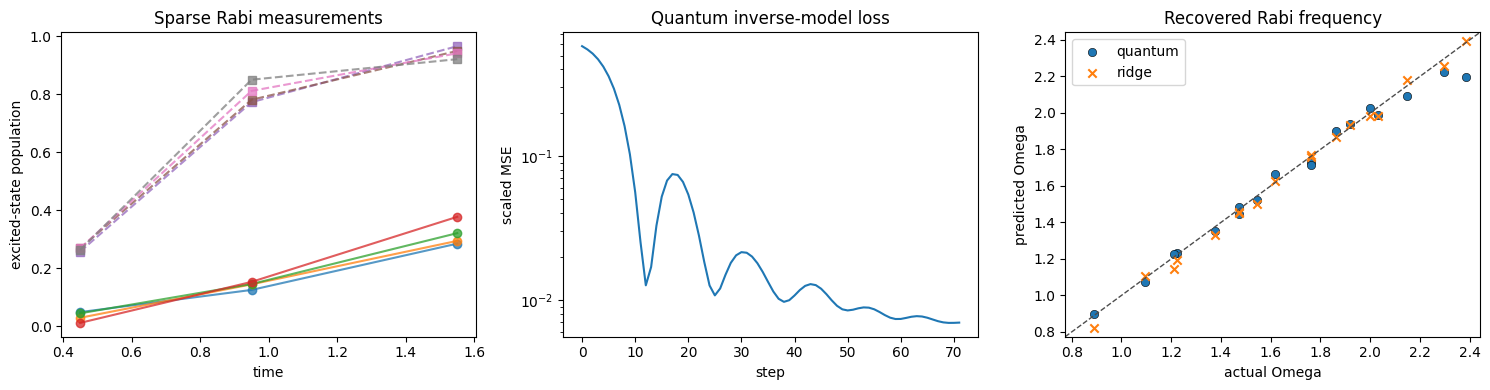

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx in np.argsort(omega)[:4]:
    axes[0].plot(times, populations[idx], "o-", alpha=0.75)
for idx in np.argsort(omega)[-4:]:
    axes[0].plot(times, populations[idx], "s--", alpha=0.75)
axes[0].set_title("Sparse Rabi measurements")
axes[0].set_xlabel("time")
axes[0].set_ylabel("excited-state population")

axes[1].plot(loss_history, color="tab:blue")
axes[1].set_title("Quantum inverse-model loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("scaled MSE")
axes[1].set_yscale("log")

limit_low = min(omega_test.min(), q_omega_pred.min(), ridge_omega_pred.min()) - 0.05
limit_high = max(omega_test.max(), q_omega_pred.max(), ridge_omega_pred.max()) + 0.05
axes[2].scatter(omega_test, q_omega_pred, label="quantum", edgecolor="black", linewidth=0.4)
axes[2].scatter(omega_test, ridge_omega_pred, label="ridge", marker="x")
axes[2].plot(
    [limit_low, limit_high], [limit_low, limit_high], color="0.3", linestyle="--", linewidth=1
)
axes[2].set_xlim(limit_low, limit_high)
axes[2].set_ylim(limit_low, limit_high)
axes[2].set_title("Recovered Rabi frequency")
axes[2].set_xlabel("actual Omega")
axes[2].set_ylabel("predicted Omega")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell prints the recovered Rabi frequencies and checks that the inverse model trained and recovered `Omega` within a useful tolerance.

In [7]:
validation = {
    "dataset": {
        "problem": "rabi_frequency_inference",
        "features": [f"P_e(t={time})" for time in times.tolist()],
        "target": "rabi_frequency_omega",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
    },
    "results": results,
    "sample_recoveries": [
        {"actual_omega": float(a), "quantum_omega": float(q), "ridge_omega": float(r)}
        for a, q, r in zip(omega_test[:6], q_omega_pred[:6], ridge_omega_pred[:6])
    ],
    "passed": bool(
        np.isfinite(q_omega_pred).all()
        and results["final_loss"] < results["initial_loss"]
        and results["quantum_omega_mae"] < 0.45
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Features", validation["dataset"]["features"]),
        ("Target", validation["dataset"]["target"]),
        ("Train samples", validation["dataset"]["n_train"]),
        ("Test samples", validation["dataset"]["n_test"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum omega MAE", validation["results"]["quantum_omega_mae"]),
        ("Quantum omega MSE", validation["results"]["quantum_omega_mse"]),
        ("Ridge omega MAE", validation["results"]["ridge_omega_mae"]),
        ("Initial loss", validation["results"]["initial_loss"]),
        ("Final loss", validation["results"]["final_loss"]),
        ("Loss steps", validation["results"]["loss_steps"]),
    ],
)
print("Sample recoveries")
for index, row in enumerate(validation["sample_recoveries"], start=1):
    print(
        f"{index}. Actual Omega: {row['actual_omega']:.6f}, "
        f"Quantum Omega: {row['quantum_omega']:.6f}, "
        f"Ridge Omega: {row['ridge_omega']:.6f}"
    )
print()
print("Interpretation")
print(
    "The quantum inverse model trained successfully and recovers Rabi frequency within the validation tolerance."
)
print(
    "The baseline is included as a sanity check; this validates package usage rather than quantum advantage."
)
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+---------------+-----------------------------------------+
| Metric        | Value                                   |
+---------------+-----------------------------------------+
| Problem       | rabi_frequency_inference                |
| Features      | [P_e(t=0.45), P_e(t=0.95), P_e(t=1.55)] |
| Target        | rabi_frequency_omega                    |
| Train samples | 40                                      |
| Test samples  | 18                                      |
+---------------+-----------------------------------------+

Results
+-------------------+------------+
| Metric            | Value      |
+-------------------+------------+
| Quantum omega MAE | 0.0393237  |
| Quantum omega MSE | 0.00319466 |
| Ridge omega MAE   | 0.0273694  |
| Initial loss      | 0.580552   |
| Final loss        | 0.00697781 |
| Loss steps        | 72         |
+-------------------+------------+

Sample recoveries
1. Actual Omega: 1.999511, Quantum Omega: 2.027799, Ridge Omega